In [1]:
%pip uninstall -y matplotlib matplotlib-inline
%pip install --no-cache-dir --force-reinstall "matplotlib==3.8.4" matplotlib-inline

Found existing installation: matplotlib 3.11.0
Note: you may need to restart the kernel to use updated packages.


error: uninstall-no-record-file

Cannot uninstall matplotlib 3.11.0

The package's contents are unknown: no RECORD file was found for matplotlib.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps matplotlib==3.11.0


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/7.7 MB ? eta -:--:--
   ---------------------------------------- 7.7/7.7 MB 94.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 130.9 MB/s  0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 12.6/12.6 MB 87.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 108.3 MB/s  0:00:00

  Attempting uninstall: traitlets

    Found existing installation: traitlets 5.15.1

    Uninstalling traitlets-5.15.1:

      Successfully uninstalled traitlets-5.15.1

   ----------------------------------------  0/13 [traitlets]
  Attempting uninstall: six
   ----------------------------------------  0/13 [traitlets]
    Found existing install

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
error: uninstall-no-record-file

Cannot uninstall matplotlib 3.11.0

The package's contents are unknown: no RECORD file was found for matplotlib.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps matplotlib==3.11.0


In [2]:
import os
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display

import matplotlib.pyplot as plt

from pymatgen.core import Composition, Element

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

from scipy.stats import spearmanr
import joblib

warnings.filterwarnings("ignore")

BASE_DIR = Path("sodium_cathode_ml_protocols")
INPUT_DIR = BASE_DIR / "input"
OUTPUT_DIR = BASE_DIR / "outputs"
METRICS_DIR = OUTPUT_DIR / "metrics"
PRED_DIR = OUTPUT_DIR / "predictions"
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
FEATURE_DIR = OUTPUT_DIR / "features"
TABLE_DIR = OUTPUT_DIR / "tables"

for folder in [BASE_DIR, INPUT_DIR, OUTPUT_DIR, METRICS_DIR, PRED_DIR, FIG_DIR, MODEL_DIR, FEATURE_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print("Project folder:", BASE_DIR.resolve())

Project folder: C:\Users\IICT-1\next sustainability\code 3\sodium_cathode_ml_protocols


In [3]:
def find_first_existing(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    raise FileNotFoundError(
        "None of these files were found:\n" + "\n".join(str(x) for x in candidates)
    )


MASTER_PATH = find_first_existing([
    Path("mp_na_electrodes_master_v1_with_cde_evidence.csv"),
    Path("sodium_cathode_cde_matching/outputs/mp_na_electrodes_master_v1_with_cde_evidence.csv"),
    Path("/mnt/data/mp_na_electrodes_master_v1_with_cde_evidence.csv"),
])

AUDIT_PATH = find_first_existing([
    Path("cde_matching_audit_summary.csv"),
    Path("sodium_cathode_cde_matching/audit/cde_matching_audit_summary.csv"),
    Path("/mnt/data/cde_matching_audit_summary.csv"),
])

TOP_EVIDENCE_PATH = find_first_existing([
    Path("top_conservative_candidates_with_cde_evidence.csv"),
    Path("sodium_cathode_cde_matching/outputs/top_conservative_candidates_with_cde_evidence.csv"),
    Path("/mnt/data/top_conservative_candidates_with_cde_evidence.csv"),
])

df = pd.read_csv(MASTER_PATH)
df_audit = pd.read_csv(AUDIT_PATH)
df_top_evidence = pd.read_csv(TOP_EVIDENCE_PATH)

print("Master dataset:", MASTER_PATH)
print("Shape:", df.shape)

print("\nAudit summary:")
display(df_audit)

print("\nTop CDE-supported conservative candidates:")
display(df_top_evidence.head(20))

Master dataset: mp_na_electrodes_master_v1_with_cde_evidence.csv
Shape: (416, 258)

Audit summary:


,metric,value
0,mp_database_version,2026.04.13
1,mp_total_records,416
2,mp_basic_screening_pass,164
3,mp_hard_exclusion_free_candidates,112
4,mp_conservative_earth_abundant_candidates,56
5,cde_merged_rows,214617
6,cde_formula_records,354598
7,cde_formula_records_clean_no_LR,279505
8,cde_na_cathode_clean_filtered_records,13995
9,cde_aggregated_formula_property_rows,24552



Top CDE-supported conservative candidates:


,battery_formula,formula_discharge,framework_formula,preliminary_family,average_voltage,capacity_grav,energy_grav,max_delta_volume,stability_charge,stability_discharge,...,conservative_earth_abundant_candidate,hard_exclusion_free_candidate,cde_exact_formula_match,cde_matched_reduced_formulas,cde_capacity_median,cde_voltage_median,cde_energy_median,cde_capacity_record_count,cde_voltage_record_count,cde_total_doi_count
0,Na0-2MnPO4F,Na2MnPO4F,MnPO4F,phosphate_or_NASICON_like,3.864973,249.446804,964.105080,0.286562,0.035308,0.000000,...,True,True,True,Na2MnPO4F,113.0000,4.5000,511.010000,92.0,28.0,38.0
1,Na0-2MnP2O7,Na2MnP2O7,MnP2O7,phosphate_or_NASICON_like,4.058779,195.018501,791.536945,0.123101,0.072623,0.000365,...,True,True,True,Na2MnP2O7,83.7000,3.5000,300.000000,30.0,12.0,28.0
2,Na1-3MnPCO7,Na3MnPCO7,MnPCO7,phosphate_or_NASICON_like,3.369558,192.202735,647.638332,0.073266,0.000000,0.000000,...,True,True,True,Na3MnPCO7,125.0000,4.4000,467.480882,30.0,6.0,28.0
3,Na1-3FePCO7,Na3FePCO7,FePCO7,phosphate_or_NASICON_like,3.443900,191.579709,659.781296,0.010975,0.040622,0.000000,...,True,True,True,Na3FePCO7,96.0000,4.4000,405.120000,2.0,2.0,6.0
4,Na0-1CuPO4,NaCuPO4,CuPO4,phosphate_or_NASICON_like,3.827827,147.660761,565.219775,0.119355,0.005488,0.027283,...,True,True,True,CuPO4,NaN,3.6000,NaN,NaN,6.0,2.0
5,Na0-1MnO2,NaMnO2,MnO2,transition_metal_oxide_like,2.745589,243.812486,669.408995,0.075650,0.013759,0.000000,...,True,True,True,"MnO2,NaMnO2",312.0000,2.2600,432.616982,2732.0,1232.0,2166.0
6,Na0-1MnO2,NaMnO2,MnO2,transition_metal_oxide_like,2.692695,243.812486,656.512717,0.163210,0.015144,0.014262,...,True,True,True,"MnO2,NaMnO2",312.0000,2.2600,432.616982,2732.0,1232.0,2166.0
7,Na0-1MnPO4,NaMnPO4,MnPO4,phosphate_or_NASICON_like,3.387074,155.012197,525.037724,0.173845,0.002637,0.000000,...,True,True,True,"MnPO4,NaMnPO4",107.4625,3.6000,185.550000,48.0,18.0,28.0
8,Na0-1MnO2,NaMnO2,MnO2,transition_metal_oxide_like,2.681036,243.812486,653.669979,0.281759,0.032930,0.030517,...,True,True,True,"MnO2,NaMnO2",312.0000,2.2600,432.616982,2732.0,1232.0,2166.0
9,Na0-1MnPO4,NaMnPO4,MnPO4,phosphate_or_NASICON_like,3.297378,155.012197,511.133787,0.205882,0.000000,0.010554,...,True,True,True,"MnPO4,NaMnPO4",107.4625,3.6000,185.550000,48.0,18.0,28.0


In [4]:
def to_bool_series(s):
    return (
        s.astype(str)
        .str.strip()
        .str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .fillna(False)
    )


bool_cols = [
    "basic_screening_pass",
    "hard_exclusion_free_candidate",
    "moderate_sustainable_candidate",
    "conservative_earth_abundant_candidate",
    "cde_exact_formula_match",
    "cde_has_capacity_evidence",
    "cde_has_voltage_evidence",
    "cde_has_capacity_and_voltage_evidence",
]

for col in bool_cols:
    if col in df.columns:
        df[col] = to_bool_series(df[col])

numeric_cols = [
    "average_voltage",
    "capacity_grav",
    "capacity_vol",
    "energy_grav",
    "energy_vol",
    "max_delta_volume",
    "stability_charge",
    "stability_discharge",
    "fracA_charge",
    "fracA_discharge",
    "max_voltage_step",
    "mp_preliminary_score",
    "cde_capacity_median",
    "cde_voltage_median",
    "cde_energy_median",
    "cde_total_doi_count",
    "cde_capacity_record_count",
    "cde_voltage_record_count",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["stability_worst"] = df[["stability_charge", "stability_discharge"]].max(axis=1)

print("Rows:", len(df))
print("Conservative candidates:", int(df.get("conservative_earth_abundant_candidate", pd.Series(False, index=df.index)).sum()))
print("Exact CDE evidence:", int(df.get("cde_exact_formula_match", pd.Series(False, index=df.index)).sum()))

display(df.head())

Rows: 416
Conservative candidates: 56
Exact CDE evidence: 153


,formula_discharge,working_ion,material_ids,formula_charge,fracA_charge,nelements,max_delta_volume,framework_formula,energy_grav,num_steps,...,cde_capacity_doi_count,cde_conductivity_doi_count,cde_coulombic_efficiency_doi_count,cde_energy_doi_count,cde_voltage_doi_count,cde_exact_formula_match,cde_has_capacity_evidence,cde_has_voltage_evidence,cde_has_capacity_and_voltage_evidence,stability_worst
0,Na2MnPO4F,Na,"[""mp-aaabxacc"", ""mp-aaabfrce""]",MnPO4F,0.000000,4,0.286562,MnPO4F,964.105080,1,...,18.0,NaN,2.0,0.0,18.0,True,True,True,True,0.035308
1,Na2MnP2O7,Na,"[""mp-aaabhhug"", ""mp-aaacbgbk"", ""mp-aaacqeli""]",MnP2O7,0.000000,3,0.123101,MnP2O7,791.536945,1,...,12.0,NaN,2.0,2.0,12.0,True,True,True,True,0.072623
2,Na2MnCSO7,Na,"[""mp-aaabqyiz"", ""mp-aaabrxto""]",MnCSO7,0.000000,4,0.212925,MnCSO7,855.363301,1,...,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0.087317
3,Na3MnPCO7,Na,"[""mp-aaabrhtw"", ""mp-aaabrsfg"", ""mp-aaabsfnd"", ...",NaMnPCO7,0.090909,4,0.073266,MnPCO7,647.638332,2,...,16.0,NaN,NaN,4.0,8.0,True,True,True,True,0.000000
4,Na4Fe2(PO4)3,Na,"[""mp-aaaabnik"", ""mp-aaaabnnc"", ""mp-aaaabllc"", ...",Fe2(PO4)3,0.000000,3,0.036937,Fe2(PO4)3,868.190282,2,...,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0.096099


In [5]:
def formula_to_reduced(formula):
    if pd.isna(formula):
        return None
    try:
        return Composition(str(formula)).reduced_formula
    except Exception:
        return None


def choose_model_formula(row):
    """
    Use discharge formula first because it is usually a normal full Na-containing formula.
    Avoid battery_formula like Na0-2MnPO4F for descriptor generation.
    """
    for col in ["formula_discharge", "formula_for_parsing", "framework_formula", "formula_charge"]:
        if col in row.index:
            value = row.get(col)
            if pd.notna(value) and str(value).strip():
                try:
                    Composition(str(value))
                    return str(value)
                except Exception:
                    pass
    return None


df["ml_formula"] = df.apply(choose_model_formula, axis=1)
df["ml_reduced_formula"] = df["ml_formula"].map(formula_to_reduced)

failed = df["ml_reduced_formula"].isna().sum()

print("Formula parsing failed rows:", failed)
display(df[["battery_formula", "formula_discharge", "framework_formula", "ml_formula", "ml_reduced_formula"]].head(20))

Formula parsing failed rows: 0


,battery_formula,formula_discharge,framework_formula,ml_formula,ml_reduced_formula
0,Na0-2MnPO4F,Na2MnPO4F,MnPO4F,Na2MnPO4F,Na2MnPO4F
1,Na0-2MnP2O7,Na2MnP2O7,MnP2O7,Na2MnP2O7,Na2MnP2O7
2,Na0-2MnCSO7,Na2MnCSO7,MnCSO7,Na2MnCSO7,Na2MnCSO7
3,Na1-3MnPCO7,Na3MnPCO7,MnPCO7,Na3MnPCO7,Na3MnPCO7
4,Na0-4Fe2(PO4)3,Na4Fe2(PO4)3,Fe2(PO4)3,Na4Fe2(PO4)3,Na4Fe2(PO4)3
5,Na0-2FeCSO7,Na2FeCSO7,FeCSO7,Na2FeCSO7,Na2FeCSO7
6,Na2-6Fe2C4SO16,Na6Fe2C4SO16,Fe2C4SO16,Na6Fe2C4SO16,Na6Fe2C4SO16
7,Na1-3FePCO7,Na3FePCO7,FePCO7,Na3FePCO7,Na3FePCO7
8,Na0-1CuPO4,NaCuPO4,CuPO4,NaCuPO4,NaCuPO4
9,Na0-6Mn3(PO4)4,Na6Mn3(PO4)4,Mn3(PO4)4,Na6Mn3(PO4)4,Na6Mn3(PO4)4


In [6]:
MAIN_ELEMENTS = [
    "Na", "O", "P", "F", "S", "C", "N", "Si",
    "Fe", "Mn", "Ti", "Cu", "V", "Cr", "Co", "Ni",
    "Mo", "W", "Al", "Mg", "Ca", "K"
]

ELEMENT_PROPS = [
    "Z",
    "atomic_mass",
    "X",
    "row",
    "group",
    "atomic_radius",
]


def safe_element_prop(el_symbol, prop):
    try:
        el = Element(el_symbol)

        if prop == "Z":
            return float(el.Z)

        if prop == "atomic_mass":
            return float(el.atomic_mass)

        if prop == "X":
            return float(el.X) if el.X is not None else np.nan

        if prop == "row":
            return float(el.row)

        if prop == "group":
            return float(el.group)

        if prop == "atomic_radius":
            return float(el.atomic_radius) if el.atomic_radius is not None else np.nan

    except Exception:
        return np.nan

    return np.nan


def weighted_stats(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)

    if mask.sum() == 0:
        return {
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "max": np.nan,
            "range": np.nan,
        }

    values = values[mask]
    weights = weights[mask] / weights[mask].sum()

    mean = np.sum(values * weights)
    var = np.sum(weights * (values - mean) ** 2)

    return {
        "mean": mean,
        "std": math.sqrt(var),
        "min": np.min(values),
        "max": np.max(values),
        "range": np.max(values) - np.min(values),
    }


def composition_descriptors(formula):
    features = {}

    if pd.isna(formula):
        return features

    try:
        comp = Composition(str(formula))
        el_amt = comp.get_el_amt_dict()
        total_atoms = sum(el_amt.values())
        elements = list(el_amt.keys())
        weights = np.array([el_amt[e] / total_atoms for e in elements], dtype=float)

        features["comp__total_atoms"] = total_atoms
        features["comp__n_elements"] = len(elements)

        for e in MAIN_ELEMENTS:
            features[f"comp__frac_{e}"] = el_amt.get(e, 0.0) / total_atoms

        transition_metals = {"Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn", "Mo", "W"}
        anions = {"O", "F", "S", "N", "C"}

        features["comp__transition_metal_frac"] = sum(
            el_amt.get(e, 0.0) for e in transition_metals
        ) / total_atoms

        features["comp__anion_frac"] = sum(
            el_amt.get(e, 0.0) for e in anions
        ) / total_atoms

        features["comp__polyanion_indicator_PO"] = float(("P" in elements) and ("O" in elements))
        features["comp__oxide_indicator"] = float("O" in elements)
        features["comp__fluoride_indicator"] = float("F" in elements)
        features["comp__sulfate_like_indicator"] = float(("S" in elements) and ("O" in elements))
        features["comp__carbon_indicator"] = float("C" in elements)

        for prop in ELEMENT_PROPS:
            vals = [safe_element_prop(e, prop) for e in elements]
            stats = weighted_stats(vals, weights)

            for stat_name, stat_value in stats.items():
                features[f"comp__{prop}_{stat_name}"] = stat_value

    except Exception:
        pass

    return features


descriptor_rows = [composition_descriptors(f) for f in tqdm(df["ml_formula"], desc="Composition descriptors")]
df_comp = pd.DataFrame(descriptor_rows)

print("Composition descriptor shape:", df_comp.shape)
display(df_comp.head())

comp_path = FEATURE_DIR / "protocol_A_composition_descriptors.csv"
df_comp.to_csv(comp_path, index=False)
print("Saved:", comp_path)

Composition descriptors:   0%|          | 0/416 [00:00<?, ?it/s]

Composition descriptor shape: (416, 61)


,comp__total_atoms,comp__n_elements,comp__frac_Na,comp__frac_O,comp__frac_P,comp__frac_F,comp__frac_S,comp__frac_C,comp__frac_N,comp__frac_Si,...,comp__group_mean,comp__group_std,comp__group_min,comp__group_max,comp__group_range,comp__atomic_radius_mean,comp__atomic_radius_std,comp__atomic_radius_min,comp__atomic_radius_max,comp__atomic_radius_range
0,9.0,5,0.222222,0.444444,0.111111,0.111111,0.000000,0.000000,0.0,0.0,...,11.666667,6.359595,1.0,17.0,16.0,0.988889,0.508690,0.5,1.8,1.3
1,12.0,4,0.166667,0.583333,0.166667,0.000000,0.000000,0.000000,0.0,0.0,...,12.583333,5.722155,1.0,16.0,15.0,0.933333,0.457044,0.6,1.8,1.2
2,12.0,5,0.166667,0.583333,0.000000,0.000000,0.083333,0.083333,0.0,0.0,...,12.583333,5.736700,1.0,16.0,15.0,0.908333,0.460902,0.6,1.8,1.2
3,13.0,5,0.230769,0.538462,0.076923,0.000000,0.000000,0.076923,0.0,0.0,...,11.615385,6.270057,1.0,16.0,15.0,0.976923,0.502538,0.6,1.8,1.2
4,21.0,4,0.190476,0.571429,0.142857,0.000000,0.000000,0.000000,0.0,0.0,...,12.238095,5.911287,1.0,16.0,15.0,0.961905,0.476571,0.6,1.8,1.2


Saved: sodium_cathode_ml_protocols\outputs\features\protocol_A_composition_descriptors.csv


In [7]:
df_features = pd.concat(
    [
        df.reset_index(drop=True),
        df_comp.reset_index(drop=True),
    ],
    axis=1,
)

PROTOCOL_A_FEATURES = [c for c in df_features.columns if c.startswith("comp__")]

# Protocol B: composition + simple structural/lattice descriptors
PROTOCOL_B_EXTRA = [
    "host_structure__lattice__a",
    "host_structure__lattice__b",
    "host_structure__lattice__c",
    "host_structure__lattice__alpha",
    "host_structure__lattice__beta",
    "host_structure__lattice__gamma",
    "host_structure__lattice__volume",
]

PROTOCOL_B_EXTRA = [c for c in PROTOCOL_B_EXTRA if c in df_features.columns]
PROTOCOL_B_FEATURES = PROTOCOL_A_FEATURES + PROTOCOL_B_EXTRA

# Protocol C-strict: post-DFT electrode descriptors but no direct target columns, no CDE, no scores
PROTOCOL_C_EXTRA = [
    "fracA_charge",
    "fracA_discharge",
    "max_delta_volume",
    "stability_charge",
    "stability_discharge",
]

PROTOCOL_C_EXTRA = [c for c in PROTOCOL_C_EXTRA if c in df_features.columns]
PROTOCOL_C_FEATURES = PROTOCOL_B_FEATURES + PROTOCOL_C_EXTRA

feature_manifest = {
    "Protocol_A_composition_only": PROTOCOL_A_FEATURES,
    "Protocol_B_composition_plus_lattice": PROTOCOL_B_FEATURES,
    "Protocol_C_strict_post_DFT": PROTOCOL_C_FEATURES,
    "excluded_from_main_ML": [
        "average_voltage",
        "capacity_grav",
        "capacity_vol",
        "energy_grav",
        "energy_vol",
        "max_voltage_step",
        "mp_preliminary_score",
        "cde_capacity_median",
        "cde_voltage_median",
        "cde_energy_median",
        "cde_total_doi_count",
        "candidate labels",
        "screening scores",
    ],
}

manifest_path = FEATURE_DIR / "protocol_feature_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(feature_manifest, f, indent=2)

print("Protocol A features:", len(PROTOCOL_A_FEATURES))
print("Protocol B features:", len(PROTOCOL_B_FEATURES))
print("Protocol C-strict features:", len(PROTOCOL_C_FEATURES))
print("Saved:", manifest_path)

Protocol A features: 61
Protocol B features: 68
Protocol C-strict features: 73
Saved: sodium_cathode_ml_protocols\outputs\features\protocol_feature_manifest.json


In [8]:
TARGET_CONFIG = {
    "average_voltage": {
        "higher_is_better": True,
        "unit": "V",
    },
    "capacity_grav": {
        "higher_is_better": True,
        "unit": "mAh/g",
    },
    "energy_grav": {
        "higher_is_better": True,
        "unit": "Wh/kg",
    },
    "stability_worst": {
        "higher_is_better": False,
        "unit": "eV/atom",
    },
}

# Group by framework formula to reduce leakage from near-duplicate electrode entries.
if "framework_formula" in df_features.columns:
    df_features["cv_group"] = df_features["framework_formula"].fillna(df_features["ml_reduced_formula"]).astype(str)
else:
    df_features["cv_group"] = df_features["ml_reduced_formula"].astype(str)

print("Unique CV groups:", df_features["cv_group"].nunique())
display(df_features[["battery_formula", "formula_discharge", "framework_formula", "ml_reduced_formula", "cv_group"]].head(20))

Unique CV groups: 321


,battery_formula,formula_discharge,framework_formula,ml_reduced_formula,cv_group
0,Na0-2MnPO4F,Na2MnPO4F,MnPO4F,Na2MnPO4F,MnPO4F
1,Na0-2MnP2O7,Na2MnP2O7,MnP2O7,Na2MnP2O7,MnP2O7
2,Na0-2MnCSO7,Na2MnCSO7,MnCSO7,Na2MnCSO7,MnCSO7
3,Na1-3MnPCO7,Na3MnPCO7,MnPCO7,Na3MnPCO7,MnPCO7
4,Na0-4Fe2(PO4)3,Na4Fe2(PO4)3,Fe2(PO4)3,Na4Fe2(PO4)3,Fe2(PO4)3
5,Na0-2FeCSO7,Na2FeCSO7,FeCSO7,Na2FeCSO7,FeCSO7
6,Na2-6Fe2C4SO16,Na6Fe2C4SO16,Fe2C4SO16,Na6Fe2C4SO16,Fe2C4SO16
7,Na1-3FePCO7,Na3FePCO7,FePCO7,Na3FePCO7,FePCO7
8,Na0-1CuPO4,NaCuPO4,CuPO4,NaCuPO4,CuPO4
9,Na0-6Mn3(PO4)4,Na6Mn3(PO4)4,Mn3(PO4)4,Na6Mn3(PO4)4,Mn3(PO4)4


In [9]:
MODELS = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),

    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            min_samples_leaf=2,
            n_jobs=-1,
        )),
    ]),

    "ExtraTrees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            min_samples_leaf=2,
            n_jobs=-1,
        )),
    ]),

    "GradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            random_state=RANDOM_STATE,
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
        )),
    ]),
}

print("Models:", list(MODELS.keys()))

Models: ['Ridge', 'RandomForest', 'ExtraTrees', 'GradientBoosting']


In [10]:
# Fixed Cell 9A — Create/check unique row ID for safe ML merging

if "mp_index" not in df_features.columns:
    df_features["mp_index"] = np.arange(len(df_features))

if "mp_index" not in df.columns:
    df["mp_index"] = np.arange(len(df))

df_features["mp_index"] = pd.to_numeric(df_features["mp_index"], errors="coerce").astype(int)
df["mp_index"] = pd.to_numeric(df["mp_index"], errors="coerce").astype(int)

assert df_features["mp_index"].is_unique, "ERROR: df_features mp_index is not unique."
assert df["mp_index"].is_unique, "ERROR: original df mp_index is not unique."

print("Row-ID check passed.")
print("df_features rows:", len(df_features))
print("original df rows:", len(df))
print("unique mp_index in df_features:", df_features["mp_index"].nunique())
print("unique mp_index in original df:", df["mp_index"].nunique())

display(df_features[["mp_index", "battery_formula", "formula_discharge", "framework_formula"]].head())


Row-ID check passed.
df_features rows: 416
original df rows: 416
unique mp_index in df_features: 416
unique mp_index in original df: 416


,mp_index,battery_formula,formula_discharge,framework_formula
0,0,Na0-2MnPO4F,Na2MnPO4F,MnPO4F
1,1,Na0-2MnP2O7,Na2MnP2O7,MnP2O7
2,2,Na0-2MnCSO7,Na2MnCSO7,MnCSO7
3,3,Na1-3MnPCO7,Na3MnPCO7,MnPCO7
4,4,Na0-4Fe2(PO4)3,Na4Fe2(PO4)3,Fe2(PO4)3


In [11]:
# Fixed Cell 10 — Cross-validation functions with mp_index preserved

def clean_feature_list_for_target(feature_cols, target_name):
    """
    Remove target-leaking fields for each target/protocol.
    CDE evidence and candidate labels are never allowed as main ML features.
    """
    feature_cols = list(feature_cols)
    remove = set()

    if target_name == "stability_worst":
        remove.update(["stability_charge", "stability_discharge"])

    remove.add(target_name)

    forbidden_prefixes = ["cde_", "valid_", "score"]
    forbidden_exact = {
        "average_voltage",
        "capacity_grav",
        "capacity_vol",
        "energy_grav",
        "energy_vol",
        "max_voltage_step",
        "mp_preliminary_score",
        "voltage_score",
        "capacity_score",
        "energy_score",
        "volume_score",
        "stability_score",
        "criticality_score",
        "basic_screening_pass",
        "hard_exclusion_free_candidate",
        "moderate_sustainable_candidate",
        "conservative_earth_abundant_candidate",
        "cde_exact_formula_match",
        "cde_has_capacity_evidence",
        "cde_has_voltage_evidence",
        "cde_has_capacity_and_voltage_evidence",
    }

    safe_cols = []

    for c in feature_cols:
        if c in remove:
            continue
        if c in forbidden_exact:
            continue
        if any(str(c).startswith(prefix) for prefix in forbidden_prefixes):
            continue
        safe_cols.append(c)

    return safe_cols


def make_cv_splitter(y, groups, n_splits=5):
    """
    Use GroupKFold when framework groups exist.
    Fallback to KFold only if grouping is impossible.
    """
    groups = pd.Series(groups).astype(str).fillna("missing_group")
    unique_groups = groups.nunique()

    if unique_groups >= 2:
        k = min(n_splits, unique_groups)
        return GroupKFold(n_splits=k), groups

    k = min(n_splits, len(y))
    return KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE), None


def top_fraction_enrichment(y_true, y_pred, higher_is_better=True, frac=0.20):
    """
    Measures whether the model retrieves the true top-performing candidates.
    Enrichment > 1 is better than random.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    n = len(y_true)

    if n < 5:
        return np.nan

    k = max(1, int(np.ceil(frac * n)))

    if higher_is_better:
        true_top = set(np.argsort(y_true)[-k:])
        pred_top = set(np.argsort(y_pred)[-k:])
    else:
        true_top = set(np.argsort(y_true)[:k])
        pred_top = set(np.argsort(y_pred)[:k])

    observed_overlap = len(true_top & pred_top)
    expected_overlap = k * k / n

    if expected_overlap == 0:
        return np.nan

    return observed_overlap / expected_overlap


def evaluate_predictions(y_true, y_pred, higher_is_better=True):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = np.nan

    try:
        spearman = spearmanr(y_true, y_pred).correlation
    except Exception:
        spearman = np.nan

    enrichment_20 = top_fraction_enrichment(
        y_true,
        y_pred,
        higher_is_better=higher_is_better,
        frac=0.20,
    )

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "spearman": spearman,
        "top20_enrichment": enrichment_20,
    }


def run_grouped_cv(df_input, feature_cols, target_name, protocol_name, model_name, model):
    """
    Run grouped cross-validation and preserve mp_index for safe later merging.
    """
    feature_cols = clean_feature_list_for_target(feature_cols, target_name)

    required_meta_cols = [
        "mp_index",
        "cv_group",
        "battery_formula",
        "formula_discharge",
        "framework_formula",
        "preliminary_family",
    ]

    available_meta_cols = [
        c for c in required_meta_cols
        if c in df_input.columns
    ]

    if "mp_index" not in available_meta_cols:
        raise ValueError("mp_index missing. Run Fixed Cell 9A first.")

    if "cv_group" not in available_meta_cols:
        raise ValueError("cv_group missing. Run original Cell 8 first.")

    model_df = df_input[
        feature_cols + [target_name] + available_meta_cols
    ].copy()

    model_df[target_name] = pd.to_numeric(model_df[target_name], errors="coerce")
    model_df = model_df[model_df[target_name].notna()].reset_index(drop=True)

    X = model_df[feature_cols]
    y = model_df[target_name].values
    groups = model_df["cv_group"]

    splitter, split_groups = make_cv_splitter(y, groups, n_splits=5)

    oof_pred = np.full(len(model_df), np.nan)

    for fold, (train_idx, test_idx) in enumerate(
        splitter.split(X, y, groups=split_groups),
        start=1,
    ):
        est = clone(model)
        est.fit(X.iloc[train_idx], y[train_idx])
        oof_pred[test_idx] = est.predict(X.iloc[test_idx])

    higher_is_better = TARGET_CONFIG[target_name]["higher_is_better"]
    metrics = evaluate_predictions(
        y,
        oof_pred,
        higher_is_better=higher_is_better,
    )

    baseline_pred = np.full_like(y, np.nanmedian(y), dtype=float)
    baseline_metrics = evaluate_predictions(
        y,
        baseline_pred,
        higher_is_better=higher_is_better,
    )

    metric_row = {
        "target": target_name,
        "unit": TARGET_CONFIG[target_name]["unit"],
        "protocol": protocol_name,
        "model": model_name,
        "n_samples": len(model_df),
        "n_features": len(feature_cols),
        "n_groups": groups.nunique(),
        **metrics,
        "baseline_rmse": baseline_metrics["rmse"],
        "baseline_mae": baseline_metrics["mae"],
    }

    pred_cols = [
        "mp_index",
        "battery_formula",
        "formula_discharge",
        "framework_formula",
        "preliminary_family",
        "cv_group",
        target_name,
    ]

    pred_cols = [
        c for c in pred_cols
        if c in model_df.columns
    ]

    pred_df = model_df[pred_cols].copy()
    pred_df["target"] = target_name
    pred_df["protocol"] = protocol_name
    pred_df["model"] = model_name
    pred_df["y_true"] = y
    pred_df["y_pred_oof"] = oof_pred
    pred_df["abs_error"] = np.abs(pred_df["y_true"] - pred_df["y_pred_oof"])

    return metric_row, pred_df, feature_cols


print("Fixed CV functions loaded successfully.")


Fixed CV functions loaded successfully.


In [12]:
# Fixed Cell 11 — Run grouped CV for all targets, protocols, and models

PROTOCOLS = {
    "A_composition_only": PROTOCOL_A_FEATURES,
    "B_composition_lattice": PROTOCOL_B_FEATURES,
    "C_strict_post_DFT": PROTOCOL_C_FEATURES,
}

all_metrics = []
all_predictions = []
used_feature_rows = []

for target_name in TARGET_CONFIG.keys():
    for protocol_name, feature_cols in PROTOCOLS.items():
        for model_name, model in MODELS.items():

            print(f"Running: target={target_name}, protocol={protocol_name}, model={model_name}")

            metric_row, pred_df, used_cols = run_grouped_cv(
                df_input=df_features,
                feature_cols=feature_cols,
                target_name=target_name,
                protocol_name=protocol_name,
                model_name=model_name,
                model=model,
            )

            all_metrics.append(metric_row)
            all_predictions.append(pred_df)

            used_feature_rows.append({
                "target": target_name,
                "protocol": protocol_name,
                "model": model_name,
                "n_used_features": len(used_cols),
                "used_features": json.dumps(used_cols),
            })

df_metrics = pd.DataFrame(all_metrics)
df_predictions = pd.concat(all_predictions, ignore_index=True)
df_used_features = pd.DataFrame(used_feature_rows)

metrics_path = METRICS_DIR / "ml_grouped_cv_metrics_all_targets.csv"
pred_path = PRED_DIR / "ml_grouped_cv_oof_predictions_all_targets.csv"
used_features_path = FEATURE_DIR / "ml_used_features_by_target_protocol_model.csv"

df_metrics.to_csv(metrics_path, index=False)
df_predictions.to_csv(pred_path, index=False)
df_used_features.to_csv(used_features_path, index=False)

print("Saved:", metrics_path)
print("Saved:", pred_path)
print("Saved:", used_features_path)

print("Prediction rows:", len(df_predictions))
print("Unique mp_index in predictions:", df_predictions["mp_index"].nunique())

display(
    df_metrics.sort_values(["target", "rmse"])
)


Running: target=average_voltage, protocol=A_composition_only, model=Ridge
Running: target=average_voltage, protocol=A_composition_only, model=RandomForest
Running: target=average_voltage, protocol=A_composition_only, model=ExtraTrees
Running: target=average_voltage, protocol=A_composition_only, model=GradientBoosting
Running: target=average_voltage, protocol=B_composition_lattice, model=Ridge
Running: target=average_voltage, protocol=B_composition_lattice, model=RandomForest
Running: target=average_voltage, protocol=B_composition_lattice, model=ExtraTrees
Running: target=average_voltage, protocol=B_composition_lattice, model=GradientBoosting
Running: target=average_voltage, protocol=C_strict_post_DFT, model=Ridge
Running: target=average_voltage, protocol=C_strict_post_DFT, model=RandomForest
Running: target=average_voltage, protocol=C_strict_post_DFT, model=ExtraTrees
Running: target=average_voltage, protocol=C_strict_post_DFT, model=GradientBoosting
Running: target=capacity_grav, prot

,target,unit,protocol,model,n_samples,n_features,n_groups,rmse,mae,r2,spearman,top20_enrichment,baseline_rmse,baseline_mae
11,average_voltage,V,C_strict_post_DFT,GradientBoosting,416,73,321,0.656014,0.479521,0.767949,0.872274,3.655329,1.370375,1.058348
9,average_voltage,V,C_strict_post_DFT,RandomForest,416,73,321,0.698450,0.511454,0.736956,0.850962,3.596372,1.370375,1.058348
10,average_voltage,V,C_strict_post_DFT,ExtraTrees,416,73,321,0.705138,0.501749,0.731894,0.838907,3.419501,1.370375,1.058348
3,average_voltage,V,A_composition_only,GradientBoosting,416,61,321,0.772004,0.567025,0.678636,0.805267,3.301587,1.370375,1.058348
2,average_voltage,V,A_composition_only,ExtraTrees,416,61,321,0.775115,0.558228,0.676041,0.792193,3.183673,1.370375,1.058348
6,average_voltage,V,B_composition_lattice,ExtraTrees,416,68,321,0.782687,0.560484,0.669680,0.780070,3.006803,1.370375,1.058348
7,average_voltage,V,B_composition_lattice,GradientBoosting,416,68,321,0.784001,0.580551,0.668571,0.793300,3.065760,1.370375,1.058348
1,average_voltage,V,A_composition_only,RandomForest,416,61,321,0.793577,0.587115,0.660425,0.770385,3.006803,1.370375,1.058348
5,average_voltage,V,B_composition_lattice,RandomForest,416,68,321,0.802547,0.595484,0.652705,0.761622,2.888889,1.370375,1.058348
8,average_voltage,V,C_strict_post_DFT,Ridge,416,73,321,0.860292,0.612450,0.600930,0.797888,3.360544,1.370375,1.058348


In [13]:
df_best = (
    df_metrics
    .sort_values(["target", "protocol", "rmse"], ascending=[True, True, True])
    .groupby(["target", "protocol"], as_index=False)
    .first()
)

best_path = METRICS_DIR / "ml_best_model_by_target_protocol.csv"
df_best.to_csv(best_path, index=False)

print("Saved:", best_path)
display(df_best)

Saved: sodium_cathode_ml_protocols\outputs\metrics\ml_best_model_by_target_protocol.csv


,target,protocol,unit,model,n_samples,n_features,n_groups,rmse,mae,r2,spearman,top20_enrichment,baseline_rmse,baseline_mae
0,average_voltage,A_composition_only,V,GradientBoosting,416,61,321,0.772004,0.567025,0.678636,0.805267,3.301587,1.370375,1.058348
1,average_voltage,B_composition_lattice,V,ExtraTrees,416,68,321,0.782687,0.560484,0.669680,0.780070,3.006803,1.370375,1.058348
2,average_voltage,C_strict_post_DFT,V,GradientBoosting,416,73,321,0.656014,0.479521,0.767949,0.872274,3.655329,1.370375,1.058348
3,capacity_grav,A_composition_only,mAh/g,ExtraTrees,416,61,321,44.965333,22.392974,0.797366,0.884883,3.832200,102.853545,63.041762
4,capacity_grav,B_composition_lattice,mAh/g,ExtraTrees,416,68,321,44.914129,23.360810,0.797827,0.880206,3.950113,102.853545,63.041762
5,capacity_grav,C_strict_post_DFT,mAh/g,ExtraTrees,416,73,321,32.979349,14.072800,0.890997,0.967385,4.480726,102.853545,63.041762
6,energy_grav,A_composition_only,Wh/kg,ExtraTrees,416,61,321,191.130987,113.683838,0.536193,0.828561,3.301587,283.617794,198.024415
7,energy_grav,B_composition_lattice,Wh/kg,ExtraTrees,416,68,321,188.803840,116.095793,0.547418,0.815839,3.183673,283.617794,198.024415
8,energy_grav,C_strict_post_DFT,Wh/kg,ExtraTrees,416,73,321,159.145657,90.155798,0.678438,0.887619,4.009070,283.617794,198.024415
9,stability_worst,A_composition_only,eV/atom,ExtraTrees,416,61,321,0.201011,0.084572,0.220997,0.548773,2.594104,0.234559,0.088725


In [14]:
summary_cols = [
    "target",
    "protocol",
    "model",
    "n_samples",
    "n_features",
    "n_groups",
    "rmse",
    "mae",
    "r2",
    "spearman",
    "top20_enrichment",
    "baseline_rmse",
    "baseline_mae",
]

df_summary = df_best[summary_cols].copy()

for col in ["rmse", "mae", "r2", "spearman", "top20_enrichment", "baseline_rmse", "baseline_mae"]:
    df_summary[col] = pd.to_numeric(df_summary[col], errors="coerce").round(4)

summary_path = TABLE_DIR / "table_ml_grouped_cv_summary.csv"
df_summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)
display(df_summary)

Saved: sodium_cathode_ml_protocols\outputs\tables\table_ml_grouped_cv_summary.csv


,target,protocol,model,n_samples,n_features,n_groups,rmse,mae,r2,spearman,top20_enrichment,baseline_rmse,baseline_mae
0,average_voltage,A_composition_only,GradientBoosting,416,61,321,0.7720,0.5670,0.6786,0.8053,3.3016,1.3704,1.0583
1,average_voltage,B_composition_lattice,ExtraTrees,416,68,321,0.7827,0.5605,0.6697,0.7801,3.0068,1.3704,1.0583
2,average_voltage,C_strict_post_DFT,GradientBoosting,416,73,321,0.6560,0.4795,0.7679,0.8723,3.6553,1.3704,1.0583
3,capacity_grav,A_composition_only,ExtraTrees,416,61,321,44.9653,22.3930,0.7974,0.8849,3.8322,102.8535,63.0418
4,capacity_grav,B_composition_lattice,ExtraTrees,416,68,321,44.9141,23.3608,0.7978,0.8802,3.9501,102.8535,63.0418
5,capacity_grav,C_strict_post_DFT,ExtraTrees,416,73,321,32.9793,14.0728,0.8910,0.9674,4.4807,102.8535,63.0418
6,energy_grav,A_composition_only,ExtraTrees,416,61,321,191.1310,113.6838,0.5362,0.8286,3.3016,283.6178,198.0244
7,energy_grav,B_composition_lattice,ExtraTrees,416,68,321,188.8038,116.0958,0.5474,0.8158,3.1837,283.6178,198.0244
8,energy_grav,C_strict_post_DFT,ExtraTrees,416,73,321,159.1457,90.1558,0.6784,0.8876,4.0091,283.6178,198.0244
9,stability_worst,A_composition_only,ExtraTrees,416,61,321,0.2010,0.0846,0.2210,0.5488,2.5941,0.2346,0.0887


Saved parity data: sodium_cathode_ml_protocols\outputs\figures\parity_plot_data\parity_data_average_voltage_C_strict_GradientBoosting.csv
Plot skipped for average_voltage because Matplotlib failed.
Error: 'str' object has no attribute 'size'
Saved parity data: sodium_cathode_ml_protocols\outputs\figures\parity_plot_data\parity_data_capacity_grav_C_strict_ExtraTrees.csv
Plot skipped for capacity_grav because Matplotlib failed.
Error: 'str' object has no attribute 'size'
Saved parity data: sodium_cathode_ml_protocols\outputs\figures\parity_plot_data\parity_data_energy_grav_C_strict_ExtraTrees.csv
Plot skipped for energy_grav because Matplotlib failed.
Error: 'str' object has no attribute 'size'
Saved parity data: sodium_cathode_ml_protocols\outputs\figures\parity_plot_data\parity_data_stability_worst_C_strict_ExtraTrees.csv
Plot skipped for stability_worst because Matplotlib failed.
Error: 'str' object has no attribute 'size'


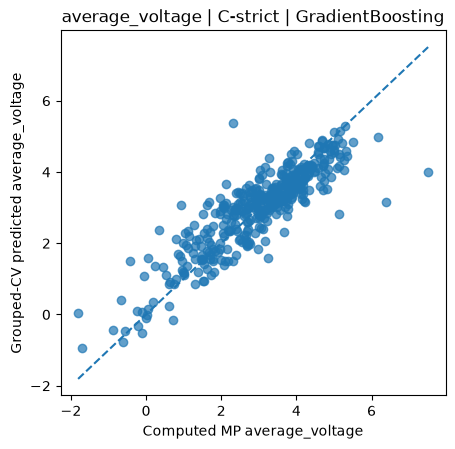

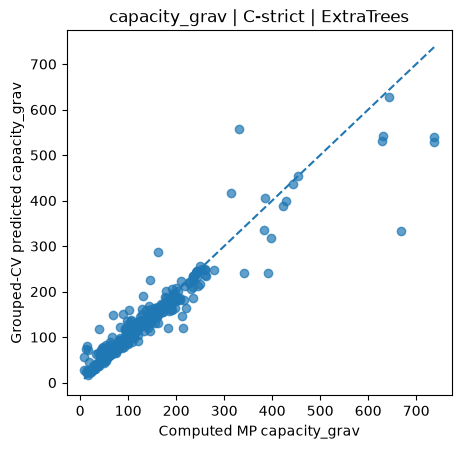

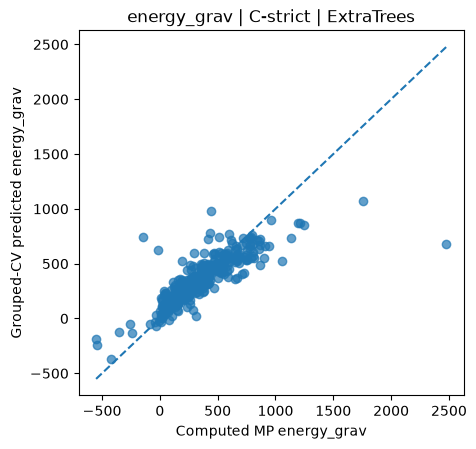

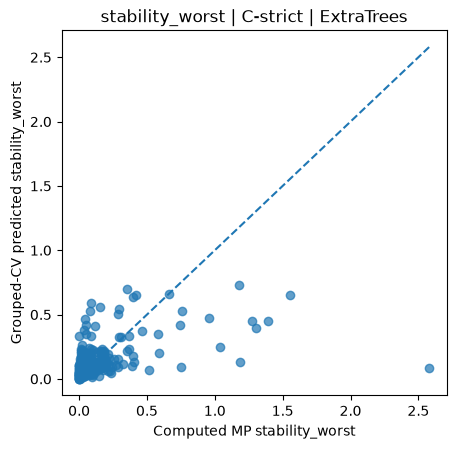

In [15]:
# Safe Cell 14 — Parity plot data + optional plots

parity_data_dir = FIG_DIR / "parity_plot_data"
parity_data_dir.mkdir(parents=True, exist_ok=True)

for target_name in TARGET_CONFIG.keys():
    row = df_best[
        (df_best["target"] == target_name)
        & (df_best["protocol"] == "C_strict_post_DFT")
    ]

    if row.empty:
        continue

    best_model_name = row.iloc[0]["model"]

    plot_df = df_predictions[
        (df_predictions["target"] == target_name)
        & (df_predictions["protocol"] == "C_strict_post_DFT")
        & (df_predictions["model"] == best_model_name)
    ].copy()

    if plot_df.empty:
        continue

    # Always save plot data, even if plotting fails
    parity_csv = parity_data_dir / f"parity_data_{target_name}_C_strict_{best_model_name}.csv"
    plot_df.to_csv(parity_csv, index=False)
    print("Saved parity data:", parity_csv)

    try:
        import matplotlib
        matplotlib.rcParams["font.enable_last_resort"] = False
        matplotlib.rcParams["font.family"] = "DejaVu Sans"

        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=(5, 5))

        ax.scatter(plot_df["y_true"], plot_df["y_pred_oof"], alpha=0.7)

        min_val = np.nanmin([plot_df["y_true"].min(), plot_df["y_pred_oof"].min()])
        max_val = np.nanmax([plot_df["y_true"].max(), plot_df["y_pred_oof"].max()])

        ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

        ax.set_xlabel(f"Computed MP {target_name}")
        ax.set_ylabel(f"Grouped-CV predicted {target_name}")
        ax.set_title(f"{target_name} | C-strict | {best_model_name}")

        # Avoid tight_layout because your error occurred there
        fig.subplots_adjust(left=0.18, right=0.95, bottom=0.15, top=0.88)

        out_plot = FIG_DIR / f"parity_{target_name}_C_strict_{best_model_name}.png"
        fig.savefig(out_plot, dpi=300, bbox_inches="standard")
        plt.close(fig)

        print("Saved plot:", out_plot)

    except Exception as e:
        print(f"Plot skipped for {target_name} because Matplotlib failed.")
        print("Error:", e)

In [16]:
importance_rows = []

for target_name in TARGET_CONFIG.keys():
    feature_cols = clean_feature_list_for_target(PROTOCOL_C_FEATURES, target_name)

    model_df = df_features[feature_cols + [target_name]].copy()
    model_df[target_name] = pd.to_numeric(model_df[target_name], errors="coerce")
    model_df = model_df[model_df[target_name].notna()].reset_index(drop=True)

    X = model_df[feature_cols]
    y = model_df[target_name].values

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=700,
            random_state=RANDOM_STATE,
            min_samples_leaf=2,
            n_jobs=-1,
        )),
    ])

    model.fit(X, y)

    fitted_tree = model.named_steps["model"]
    importances = fitted_tree.feature_importances_

    for feat, imp in zip(feature_cols, importances):
        importance_rows.append({
            "target": target_name,
            "protocol": "C_strict_post_DFT",
            "model": "ExtraTrees",
            "feature": feat,
            "importance": imp,
        })

    model_path = MODEL_DIR / f"extratrees_C_strict_{target_name}.joblib"
    joblib.dump(model, model_path)

    print("Saved model:", model_path)

df_importance = pd.DataFrame(importance_rows)
importance_path = FEATURE_DIR / "extratrees_C_strict_feature_importance.csv"
df_importance.to_csv(importance_path, index=False)

print("Saved:", importance_path)

for target_name in TARGET_CONFIG.keys():
    print("\nTop features for:", target_name)
    display(
        df_importance[df_importance["target"] == target_name]
        .sort_values("importance", ascending=False)
        .head(20)
    )

Saved model: sodium_cathode_ml_protocols\outputs\models\extratrees_C_strict_average_voltage.joblib
Saved model: sodium_cathode_ml_protocols\outputs\models\extratrees_C_strict_capacity_grav.joblib
Saved model: sodium_cathode_ml_protocols\outputs\models\extratrees_C_strict_energy_grav.joblib
Saved model: sodium_cathode_ml_protocols\outputs\models\extratrees_C_strict_stability_worst.joblib
Saved: sodium_cathode_ml_protocols\outputs\features\extratrees_C_strict_feature_importance.csv

Top features for: average_voltage


,target,protocol,model,feature,importance
41,average_voltage,C_strict_post_DFT,ExtraTrees,comp__X_mean,0.074943
48,average_voltage,C_strict_post_DFT,ExtraTrees,comp__row_min,0.074060
56,average_voltage,C_strict_post_DFT,ExtraTrees,comp__atomic_radius_mean,0.065469
12,average_voltage,C_strict_post_DFT,ExtraTrees,comp__frac_Ti,0.064122
58,average_voltage,C_strict_post_DFT,ExtraTrees,comp__atomic_radius_min,0.059714
71,average_voltage,C_strict_post_DFT,ExtraTrees,stability_charge,0.043236
60,average_voltage,C_strict_post_DFT,ExtraTrees,comp__atomic_radius_range,0.042208
45,average_voltage,C_strict_post_DFT,ExtraTrees,comp__X_range,0.042035
51,average_voltage,C_strict_post_DFT,ExtraTrees,comp__group_mean,0.041799
44,average_voltage,C_strict_post_DFT,ExtraTrees,comp__X_max,0.040376



Top features for: capacity_grav


,target,protocol,model,feature,importance
75,capacity_grav,C_strict_post_DFT,ExtraTrees,comp__frac_Na,0.215305
142,capacity_grav,C_strict_post_DFT,ExtraTrees,fracA_discharge,0.199959
143,capacity_grav,C_strict_post_DFT,ExtraTrees,max_delta_volume,0.090420
74,capacity_grav,C_strict_post_DFT,ExtraTrees,comp__n_elements,0.069383
141,capacity_grav,C_strict_post_DFT,ExtraTrees,fracA_charge,0.056193
124,capacity_grav,C_strict_post_DFT,ExtraTrees,comp__group_mean,0.035372
122,capacity_grav,C_strict_post_DFT,ExtraTrees,comp__row_max,0.024380
127,capacity_grav,C_strict_post_DFT,ExtraTrees,comp__group_max,0.020894
128,capacity_grav,C_strict_post_DFT,ExtraTrees,comp__group_range,0.020076
140,capacity_grav,C_strict_post_DFT,ExtraTrees,host_structure__lattice__volume,0.017452



Top features for: energy_grav


,target,protocol,model,feature,importance
216,energy_grav,C_strict_post_DFT,ExtraTrees,max_delta_volume,0.077789
217,energy_grav,C_strict_post_DFT,ExtraTrees,stability_charge,0.057276
214,energy_grav,C_strict_post_DFT,ExtraTrees,fracA_charge,0.057030
215,energy_grav,C_strict_post_DFT,ExtraTrees,fracA_discharge,0.054369
148,energy_grav,C_strict_post_DFT,ExtraTrees,comp__frac_Na,0.053835
171,energy_grav,C_strict_post_DFT,ExtraTrees,comp__anion_frac,0.051546
194,energy_grav,C_strict_post_DFT,ExtraTrees,comp__row_min,0.047651
192,energy_grav,C_strict_post_DFT,ExtraTrees,comp__row_mean,0.045893
193,energy_grav,C_strict_post_DFT,ExtraTrees,comp__row_std,0.032395
204,energy_grav,C_strict_post_DFT,ExtraTrees,comp__atomic_radius_min,0.031061



Top features for: stability_worst


,target,protocol,model,feature,importance
268,stability_worst,C_strict_post_DFT,ExtraTrees,comp__row_max,0.111123
235,stability_worst,C_strict_post_DFT,ExtraTrees,comp__frac_Co,0.054351
288,stability_worst,C_strict_post_DFT,ExtraTrees,fracA_discharge,0.054072
221,stability_worst,C_strict_post_DFT,ExtraTrees,comp__frac_Na,0.051730
227,stability_worst,C_strict_post_DFT,ExtraTrees,comp__frac_N,0.048076
283,stability_worst,C_strict_post_DFT,ExtraTrees,host_structure__lattice__alpha,0.046040
289,stability_worst,C_strict_post_DFT,ExtraTrees,max_delta_volume,0.037719
270,stability_worst,C_strict_post_DFT,ExtraTrees,comp__group_mean,0.032483
260,stability_worst,C_strict_post_DFT,ExtraTrees,comp__X_mean,0.030356
253,stability_worst,C_strict_post_DFT,ExtraTrees,comp__Z_max,0.028158


Saved feature-importance data: sodium_cathode_ml_protocols\outputs\figures\feature_importance_plot_data\feature_importance_top20_average_voltage.csv
Feature-importance plot skipped for average_voltage because Matplotlib failed.
Error: 'str' object has no attribute 'size'
Saved feature-importance data: sodium_cathode_ml_protocols\outputs\figures\feature_importance_plot_data\feature_importance_top20_capacity_grav.csv
Feature-importance plot skipped for capacity_grav because Matplotlib failed.
Error: 'str' object has no attribute 'size'
Saved feature-importance data: sodium_cathode_ml_protocols\outputs\figures\feature_importance_plot_data\feature_importance_top20_energy_grav.csv
Feature-importance plot skipped for energy_grav because Matplotlib failed.
Error: 'str' object has no attribute 'size'
Saved feature-importance data: sodium_cathode_ml_protocols\outputs\figures\feature_importance_plot_data\feature_importance_top20_stability_worst.csv
Feature-importance plot skipped for stability_w

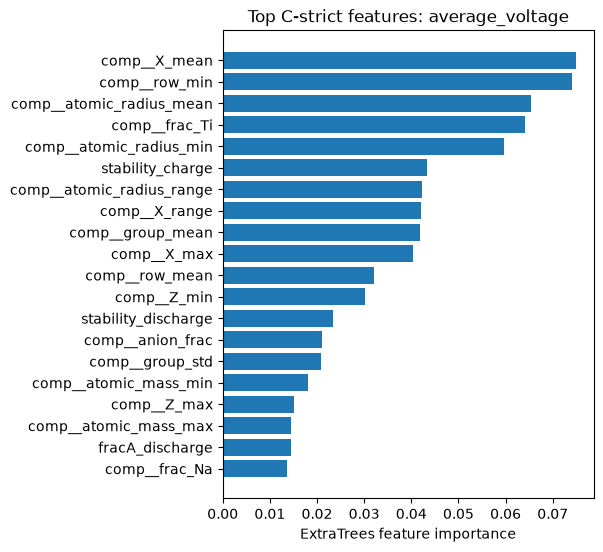

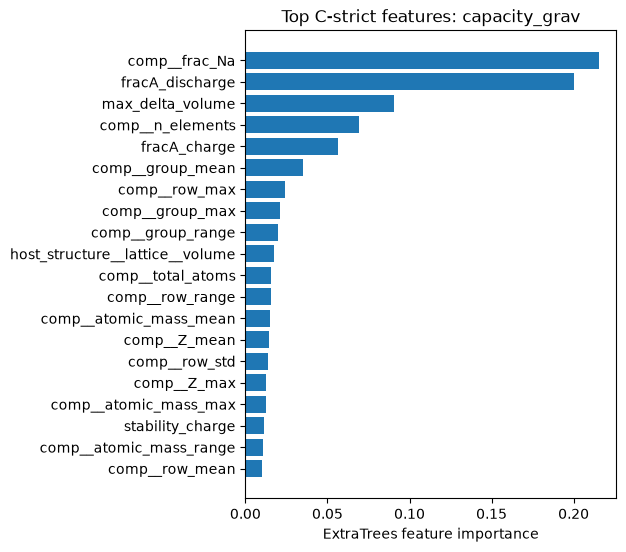

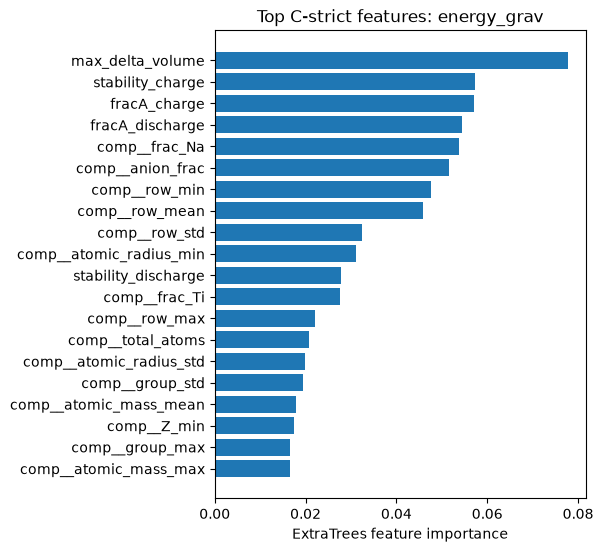

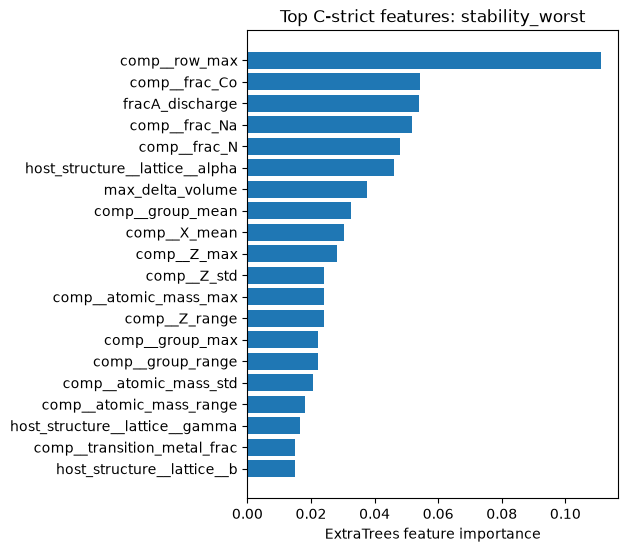

In [17]:
# Safe Cell 16 — Feature-importance plot data + optional plots

importance_plot_data_dir = FIG_DIR / "feature_importance_plot_data"
importance_plot_data_dir.mkdir(parents=True, exist_ok=True)

for target_name in TARGET_CONFIG.keys():
    tmp = (
        df_importance[df_importance["target"] == target_name]
        .sort_values("importance", ascending=False)
        .head(20)
        .sort_values("importance", ascending=True)
    )

    if tmp.empty:
        continue

    importance_csv = importance_plot_data_dir / f"feature_importance_top20_{target_name}.csv"
    tmp.to_csv(importance_csv, index=False)
    print("Saved feature-importance data:", importance_csv)

    try:
        import matplotlib
        matplotlib.rcParams["font.enable_last_resort"] = False
        matplotlib.rcParams["font.family"] = "DejaVu Sans"

        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=(7, 6))
        ax.barh(tmp["feature"], tmp["importance"])
        ax.set_xlabel("ExtraTrees feature importance")
        ax.set_title(f"Top C-strict features: {target_name}")

        # Avoid tight_layout
        fig.subplots_adjust(left=0.42, right=0.95, bottom=0.12, top=0.90)

        out_plot = FIG_DIR / f"feature_importance_C_strict_{target_name}.png"
        fig.savefig(out_plot, dpi=300, bbox_inches="standard")
        plt.close(fig)

        print("Saved plot:", out_plot)

    except Exception as e:
        print(f"Feature-importance plot skipped for {target_name} because Matplotlib failed.")
        print("Error:", e)

In [18]:
# Fixed Cell 17 — Merge best C-strict OOF predictions back to master using mp_index

df_master_ml = df.copy()

if "mp_index" not in df_master_ml.columns:
    raise ValueError("mp_index is missing from df. Run Fixed Cell 9A first.")

if "mp_index" not in df_predictions.columns:
    raise ValueError("mp_index is missing from df_predictions. Replace Cell 10 and rerun Cells 10–13 first.")

df_master_ml["mp_index"] = pd.to_numeric(
    df_master_ml["mp_index"],
    errors="coerce"
).astype(int)

df_predictions["mp_index"] = pd.to_numeric(
    df_predictions["mp_index"],
    errors="coerce"
).astype(int)

assert df_master_ml["mp_index"].is_unique, "ERROR: Original master df has duplicate mp_index."

print("Original master rows:", len(df_master_ml))
print("Unique mp_index in master:", df_master_ml["mp_index"].nunique())

for target_name in TARGET_CONFIG.keys():
    row = df_best[
        (df_best["target"] == target_name)
        & (df_best["protocol"] == "C_strict_post_DFT")
    ]

    if row.empty:
        print("No C-strict best model found for:", target_name)
        continue

    best_model_name = row.iloc[0]["model"]

    pred_df = df_predictions[
        (df_predictions["target"] == target_name)
        & (df_predictions["protocol"] == "C_strict_post_DFT")
        & (df_predictions["model"] == best_model_name)
    ][
        ["mp_index", "y_pred_oof", "abs_error"]
    ].copy()

    pred_df["mp_index"] = pd.to_numeric(
        pred_df["mp_index"],
        errors="coerce"
    ).astype(int)

    pred_df = pred_df.drop_duplicates(subset=["mp_index"], keep="first")

    assert pred_df["mp_index"].is_unique, f"ERROR: Duplicate mp_index in predictions for {target_name}"

    pred_df = pred_df.rename(columns={
        "y_pred_oof": f"ml_oof_pred_{target_name}",
        "abs_error": f"ml_oof_abs_error_{target_name}",
    })

    df_master_ml = df_master_ml.merge(
        pred_df,
        on="mp_index",
        how="left",
        validate="one_to_one"
    )

    print(
        f"Merged {target_name} predictions using best C-strict model:",
        best_model_name
    )

assert len(df_master_ml) == len(df), (
    f"ERROR: Row count changed after merging predictions: {len(df)} -> {len(df_master_ml)}"
)

master_ml_path = OUTPUT_DIR / "mp_na_electrodes_master_v2_with_ml_predictions_FIXED.csv"
df_master_ml.to_csv(master_ml_path, index=False)

print("\nSaved:", master_ml_path)
print("Fixed master shape:", df_master_ml.shape)
print("Expected rows:", len(df))

display(df_master_ml.head())


Original master rows: 416
Unique mp_index in master: 416
Merged average_voltage predictions using best C-strict model: GradientBoosting
Merged capacity_grav predictions using best C-strict model: ExtraTrees
Merged energy_grav predictions using best C-strict model: ExtraTrees
Merged stability_worst predictions using best C-strict model: ExtraTrees

Saved: sodium_cathode_ml_protocols\outputs\mp_na_electrodes_master_v2_with_ml_predictions_FIXED.csv
Fixed master shape: (416, 269)
Expected rows: 416


,formula_discharge,working_ion,material_ids,formula_charge,fracA_charge,nelements,max_delta_volume,framework_formula,energy_grav,num_steps,...,ml_formula,ml_reduced_formula,ml_oof_pred_average_voltage,ml_oof_abs_error_average_voltage,ml_oof_pred_capacity_grav,ml_oof_abs_error_capacity_grav,ml_oof_pred_energy_grav,ml_oof_abs_error_energy_grav,ml_oof_pred_stability_worst,ml_oof_abs_error_stability_worst
0,Na2MnPO4F,Na,"[""mp-aaabxacc"", ""mp-aaabfrce""]",MnPO4F,0.000000,4,0.286562,MnPO4F,964.105080,1,...,Na2MnPO4F,Na2MnPO4F,3.480536,0.384437,216.616309,32.830495,897.016441,67.088639,0.072913,0.037606
1,Na2MnP2O7,Na,"[""mp-aaabhhug"", ""mp-aaacbgbk"", ""mp-aaacqeli""]",MnP2O7,0.000000,3,0.123101,MnP2O7,791.536945,1,...,Na2MnP2O7,Na2MnP2O7,4.062906,0.004127,185.098793,9.919709,549.350716,242.186229,0.076942,0.004319
2,Na2MnCSO7,Na,"[""mp-aaabqyiz"", ""mp-aaabrxto""]",MnCSO7,0.000000,4,0.212925,MnCSO7,855.363301,1,...,Na2MnCSO7,Na2MnCSO7,3.639904,0.460970,185.069067,23.511630,637.965027,217.398274,0.068776,0.018541
3,Na3MnPCO7,Na,"[""mp-aaabrhtw"", ""mp-aaabrsfg"", ""mp-aaabsfnd"", ...",NaMnPCO7,0.090909,4,0.073266,MnPCO7,647.638332,2,...,Na3MnPCO7,Na3MnPCO7,3.218339,0.151219,187.617091,4.585644,548.661603,98.976729,0.043231,0.043231
4,Na4Fe2(PO4)3,Na,"[""mp-aaaabnik"", ""mp-aaaabnnc"", ""mp-aaaabllc"", ...",Fe2(PO4)3,0.000000,3,0.036937,Fe2(PO4)3,868.190282,2,...,Na4Fe2(PO4)3,Na4Fe2(PO4)3,3.587905,0.368646,164.789874,54.641169,487.724321,380.465961,0.068117,0.027982


In [19]:
# Fixed Cell 18 — Candidate shortlist with no row inflation

df_shortlist = df_master_ml.copy()

def clip01(x):
    return np.clip(x, 0, 1)


def safe_bool_series(s, index):
    """
    Convert mixed boolean/string/object column to clean Boolean Series.
    """
    if isinstance(s, pd.Series):
        return (
            s.astype(str)
            .str.strip()
            .str.lower()
            .map({
                "true": True,
                "false": False,
                "1": True,
                "0": False,
                "yes": True,
                "no": False,
            })
            .fillna(False)
        )

    return pd.Series(False, index=index)


numeric_for_shortlist = [
    "cde_total_doi_count",
    "mp_preliminary_score",
    "average_voltage",
    "capacity_grav",
    "energy_grav",
    "max_delta_volume",
    "stability_charge",
    "stability_discharge",
]

for col in numeric_for_shortlist:
    if col in df_shortlist.columns:
        df_shortlist[col] = pd.to_numeric(df_shortlist[col], errors="coerce")

if "cde_total_doi_count" in df_shortlist.columns:
    doi_score = np.log1p(df_shortlist["cde_total_doi_count"].fillna(0))
    denom = np.log1p(max(1, df_shortlist["cde_total_doi_count"].fillna(0).max()))
    df_shortlist["literature_support_score"] = clip01(doi_score / denom)
else:
    df_shortlist["literature_support_score"] = 0.0

conservative_bool = safe_bool_series(
    df_shortlist["conservative_earth_abundant_candidate"]
    if "conservative_earth_abundant_candidate" in df_shortlist.columns
    else None,
    df_shortlist.index
)

capacity_voltage_bool = safe_bool_series(
    df_shortlist["cde_has_capacity_and_voltage_evidence"]
    if "cde_has_capacity_and_voltage_evidence" in df_shortlist.columns
    else None,
    df_shortlist.index
)

basic_bool = safe_bool_series(
    df_shortlist["basic_screening_pass"]
    if "basic_screening_pass" in df_shortlist.columns
    else None,
    df_shortlist.index
)

hard_free_bool = safe_bool_series(
    df_shortlist["hard_exclusion_free_candidate"]
    if "hard_exclusion_free_candidate" in df_shortlist.columns
    else None,
    df_shortlist.index
)

cde_exact_bool = safe_bool_series(
    df_shortlist["cde_exact_formula_match"]
    if "cde_exact_formula_match" in df_shortlist.columns
    else None,
    df_shortlist.index
)

df_shortlist["conservative_earth_abundant_candidate_clean"] = conservative_bool
df_shortlist["hard_exclusion_free_candidate_clean"] = hard_free_bool
df_shortlist["basic_screening_pass_clean"] = basic_bool
df_shortlist["cde_exact_formula_match_clean"] = cde_exact_bool

df_shortlist["conservative_bonus"] = conservative_bool.astype(float)
df_shortlist["capacity_voltage_evidence_bonus"] = capacity_voltage_bool.astype(float)

if "mp_preliminary_score" not in df_shortlist.columns:
    df_shortlist["mp_preliminary_score"] = 0.0

df_shortlist["final_decision_support_score"] = (
    0.65 * df_shortlist["mp_preliminary_score"].fillna(0)
    + 0.20 * df_shortlist["literature_support_score"].fillna(0)
    + 0.10 * df_shortlist["conservative_bonus"].fillna(0)
    + 0.05 * df_shortlist["capacity_voltage_evidence_bonus"].fillna(0)
)

candidate_mask = basic_bool & hard_free_bool
df_candidate_shortlist = df_shortlist[candidate_mask].copy()

df_candidate_shortlist = df_candidate_shortlist.sort_values(
    by=[
        "conservative_earth_abundant_candidate_clean",
        "cde_exact_formula_match_clean",
        "final_decision_support_score",
    ],
    ascending=[False, False, False]
)

shortlist_cols = [
    "mp_index",
    "battery_formula",
    "formula_discharge",
    "framework_formula",
    "preliminary_family",
    "average_voltage",
    "capacity_grav",
    "energy_grav",
    "max_delta_volume",
    "stability_charge",
    "stability_discharge",
    "mp_preliminary_score",
    "conservative_earth_abundant_candidate",
    "hard_exclusion_free_candidate",
    "basic_screening_pass",
    "cde_exact_formula_match",
    "cde_matched_reduced_formulas",
    "cde_capacity_median",
    "cde_voltage_median",
    "cde_energy_median",
    "cde_capacity_record_count",
    "cde_voltage_record_count",
    "cde_energy_record_count",
    "cde_total_doi_count",
    "literature_support_score",
    "final_decision_support_score",
]

for target_name in TARGET_CONFIG.keys():
    for prefix in ["ml_oof_pred_", "ml_oof_abs_error_"]:
        col = f"{prefix}{target_name}"
        if col in df_candidate_shortlist.columns:
            shortlist_cols.append(col)

shortlist_cols = [
    c for c in shortlist_cols
    if c in df_candidate_shortlist.columns
]

shortlist_all_path = TABLE_DIR / "candidate_shortlist_all_records_FIXED.csv"
df_candidate_shortlist[shortlist_cols].to_csv(shortlist_all_path, index=False)

dedup_keys = [
    c for c in ["formula_discharge", "framework_formula"]
    if c in df_candidate_shortlist.columns
]

if dedup_keys:
    df_candidate_shortlist_unique = (
        df_candidate_shortlist
        .sort_values(
            by=[
                "conservative_earth_abundant_candidate_clean",
                "cde_exact_formula_match_clean",
                "final_decision_support_score",
            ],
            ascending=[False, False, False]
        )
        .drop_duplicates(subset=dedup_keys, keep="first")
        .copy()
    )
else:
    df_candidate_shortlist_unique = df_candidate_shortlist.copy()

shortlist_unique_path = TABLE_DIR / "candidate_shortlist_unique_for_manuscript_FIXED.csv"
df_candidate_shortlist_unique[shortlist_cols].to_csv(shortlist_unique_path, index=False)

print("Saved:", shortlist_all_path)
print("Saved:", shortlist_unique_path)

print("\nRow-count checks:")
print("Original master rows:", len(df_master_ml))
print("All candidate shortlist rows:", len(df_candidate_shortlist))
print("Unique manuscript shortlist rows:", len(df_candidate_shortlist_unique))

assert len(df_candidate_shortlist) <= len(df_master_ml), "ERROR: Candidate shortlist is inflated."

display(df_candidate_shortlist_unique[shortlist_cols].head(50))


Saved: sodium_cathode_ml_protocols\outputs\tables\candidate_shortlist_all_records_FIXED.csv
Saved: sodium_cathode_ml_protocols\outputs\tables\candidate_shortlist_unique_for_manuscript_FIXED.csv

Row-count checks:
Original master rows: 416
All candidate shortlist rows: 112
Unique manuscript shortlist rows: 95


,mp_index,battery_formula,formula_discharge,framework_formula,preliminary_family,average_voltage,capacity_grav,energy_grav,max_delta_volume,stability_charge,...,literature_support_score,final_decision_support_score,ml_oof_pred_average_voltage,ml_oof_abs_error_average_voltage,ml_oof_pred_capacity_grav,ml_oof_abs_error_capacity_grav,ml_oof_pred_energy_grav,ml_oof_abs_error_energy_grav,ml_oof_pred_stability_worst,ml_oof_abs_error_stability_worst
11,11,Na0-1MnO2,NaMnO2,MnO2,transition_metal_oxide_like,2.745589,243.812486,669.408995,0.075650,0.013759,...,0.887740,0.856742,2.022165,0.723424,231.308923,12.503563,635.722194,33.686801,0.180930,0.167171
0,0,Na0-2MnPO4F,Na2MnPO4F,MnPO4F,phosphate_or_NASICON_like,3.864973,249.446804,964.105080,0.286562,0.035308,...,0.423415,0.825961,3.480536,0.384437,216.616309,32.830495,897.016441,67.088639,0.072913,0.037606
1,1,Na0-2MnP2O7,Na2MnP2O7,MnP2O7,phosphate_or_NASICON_like,4.058779,195.018501,791.536945,0.123101,0.072623,...,0.389174,0.809604,4.062906,0.004127,185.098793,9.919709,549.350716,242.186229,0.076942,0.004319
3,3,Na1-3MnPCO7,Na3MnPCO7,MnPCO7,phosphate_or_NASICON_like,3.369558,192.202735,647.638332,0.073266,0.000000,...,0.389174,0.797961,3.218339,0.151219,187.617091,4.585644,548.661603,98.976729,0.043231,0.043231
27,27,Na0-0.5MnO2,NaMn2O4,MnO2,transition_metal_oxide_like,3.183568,136.142488,433.418925,0.136504,0.025370,...,0.883724,0.790721,3.244095,0.060527,137.858815,1.716327,488.072307,54.653382,0.120992,0.095622
22,22,Na0-1FePO4,NaFePO4,FePO4,phosphate_or_NASICON_like,3.072423,154.203312,473.777833,0.169556,0.029870,...,0.742551,0.776460,3.917877,0.845454,154.176028,0.027284,589.328531,115.550698,0.136012,0.106141
13,13,Na0-1MnPO4,NaMnPO4,MnPO4,phosphate_or_NASICON_like,3.387074,155.012197,525.037724,0.173845,0.002637,...,0.389174,0.751274,3.559998,0.172925,156.187725,1.175528,601.297656,76.259933,0.090895,0.088259
7,7,Na1-3FePCO7,Na3FePCO7,FePCO7,phosphate_or_NASICON_like,3.443900,191.579709,659.781296,0.010975,0.040622,...,0.224898,0.749680,3.567663,0.123763,172.059409,19.520300,582.150120,77.631176,0.048857,0.008235
26,26,Na0-0.67MnPO4,Na2Mn3(PO4)3,MnPO4,phosphate_or_NASICON_like,3.672977,108.134201,397.174405,0.078331,0.024830,...,0.372020,0.689893,3.882455,0.209478,105.512725,2.621475,432.580148,35.405743,0.057275,0.032445
8,8,Na0-1CuPO4,NaCuPO4,CuPO4,phosphate_or_NASICON_like,3.827827,147.660761,565.219775,0.119355,0.005488,...,0.126972,0.668244,3.408911,0.418916,146.728946,0.931815,563.238055,1.981720,0.044831,0.017548


In [20]:
# Fixed Cell 19 — Family-level summary without inflated rows

family_df = df_master_ml.copy()

for col in [
    "basic_screening_pass",
    "hard_exclusion_free_candidate",
    "conservative_earth_abundant_candidate",
    "cde_exact_formula_match",
]:
    if col in family_df.columns:
        family_df[col] = (
            family_df[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({
                "true": True,
                "false": False,
                "1": True,
                "0": False,
                "yes": True,
                "no": False,
            })
            .fillna(False)
        )
    else:
        family_df[col] = False

for col in [
    "average_voltage",
    "capacity_grav",
    "energy_grav",
    "mp_preliminary_score",
]:
    if col in family_df.columns:
        family_df[col] = pd.to_numeric(family_df[col], errors="coerce")

family_summary = (
    family_df
    .groupby("preliminary_family", dropna=False)
    .agg(
        n_records=("battery_formula", "size"),
        n_basic_screening=("basic_screening_pass", "sum"),
        n_hard_exclusion_free=("hard_exclusion_free_candidate", "sum"),
        n_conservative=("conservative_earth_abundant_candidate", "sum"),
        n_exact_cde=("cde_exact_formula_match", "sum"),
        median_voltage=("average_voltage", "median"),
        median_capacity=("capacity_grav", "median"),
        median_energy=("energy_grav", "median"),
        median_mp_score=("mp_preliminary_score", "median"),
    )
    .reset_index()
    .sort_values("n_conservative", ascending=False)
)

assert int(family_summary["n_records"].sum()) == len(df_master_ml), (
    "ERROR: Family summary is inflated. Check duplicate rows."
)

family_summary_path = TABLE_DIR / "family_level_summary_FIXED.csv"
family_summary.to_csv(family_summary_path, index=False)

print("Saved:", family_summary_path)
print("Total family-summary records:", int(family_summary["n_records"].sum()))
print("Expected:", len(df_master_ml))

display(family_summary)


Saved: sodium_cathode_ml_protocols\outputs\tables\family_level_summary_FIXED.csv
Total family-summary records: 416
Expected: 416


,preliminary_family,n_records,n_basic_screening,n_hard_exclusion_free,n_conservative,n_exact_cde,median_voltage,median_capacity,median_energy,median_mp_score
2,phosphate_or_NASICON_like,141,84,63,34,45,3.747225,97.925927,383.275428,0.695360
5,transition_metal_oxide_like,122,46,23,10,68,3.022559,113.687371,312.680777,0.582919
4,sulfate_like,23,21,17,9,0,3.737696,102.693871,343.118980,0.681011
3,silicate_like,18,10,9,3,0,3.340439,97.630163,323.958705,0.608164
1,other_or_unclear,107,0,0,0,38,1.903520,107.912438,170.194761,0.473439
0,carbon_or_organic_like,5,3,0,0,2,2.609895,138.649600,293.362577,0.493826


In [21]:
# Fixed Cell 20 — Final output audit and row-count checks

final_outputs = [
    METRICS_DIR / "ml_grouped_cv_metrics_all_targets.csv",
    METRICS_DIR / "ml_best_model_by_target_protocol.csv",
    TABLE_DIR / "table_ml_grouped_cv_summary.csv",
    PRED_DIR / "ml_grouped_cv_oof_predictions_all_targets.csv",
    FEATURE_DIR / "protocol_feature_manifest.json",
    FEATURE_DIR / "extratrees_C_strict_feature_importance.csv",
    OUTPUT_DIR / "mp_na_electrodes_master_v2_with_ml_predictions_FIXED.csv",
    TABLE_DIR / "candidate_shortlist_all_records_FIXED.csv",
    TABLE_DIR / "candidate_shortlist_unique_for_manuscript_FIXED.csv",
    TABLE_DIR / "family_level_summary_FIXED.csv",
]

print("Final output file audit:")

for path in final_outputs:
    status = "FOUND" if path.exists() else "MISSING"
    size_mb = path.stat().st_size / (1024 * 1024) if path.exists() else 0
    print(f"{status:7s} | {size_mb:8.2f} MB | {path}")

print("\nCritical row-count checks:")
print("Original master rows:", len(df))
print("Fixed ML master rows:", len(df_master_ml))
print("All candidate shortlist rows:", len(df_candidate_shortlist))
print("Unique manuscript shortlist rows:", len(df_candidate_shortlist_unique))
print("Family-summary total rows:", int(family_summary["n_records"].sum()))

assert len(df_master_ml) == len(df), "ERROR: Fixed ML master row count is wrong."
assert int(family_summary["n_records"].sum()) == len(df_master_ml), "ERROR: Family summary row count is wrong."
assert len(df_candidate_shortlist) <= len(df_master_ml), "ERROR: Candidate shortlist is inflated."

print("\nAll fixed checks passed.")

print("\nMost important fixed outputs:")
print("1.", METRICS_DIR / "ml_best_model_by_target_protocol.csv")
print("2.", TABLE_DIR / "table_ml_grouped_cv_summary.csv")
print("3.", OUTPUT_DIR / "mp_na_electrodes_master_v2_with_ml_predictions_FIXED.csv")
print("4.", TABLE_DIR / "candidate_shortlist_all_records_FIXED.csv")
print("5.", TABLE_DIR / "candidate_shortlist_unique_for_manuscript_FIXED.csv")
print("6.", TABLE_DIR / "family_level_summary_FIXED.csv")
print("7.", FEATURE_DIR / "extratrees_C_strict_feature_importance.csv")


Final output file audit:
FOUND   |     0.01 MB | sodium_cathode_ml_protocols\outputs\metrics\ml_grouped_cv_metrics_all_targets.csv
FOUND   |     0.00 MB | sodium_cathode_ml_protocols\outputs\metrics\ml_best_model_by_target_protocol.csv
FOUND   |     0.00 MB | sodium_cathode_ml_protocols\outputs\tables\table_ml_grouped_cv_summary.csv
FOUND   |     3.58 MB | sodium_cathode_ml_protocols\outputs\predictions\ml_grouped_cv_oof_predictions_all_targets.csv
FOUND   |     0.01 MB | sodium_cathode_ml_protocols\outputs\features\protocol_feature_manifest.json
FOUND   |     0.02 MB | sodium_cathode_ml_protocols\outputs\features\extratrees_C_strict_feature_importance.csv
FOUND   |    23.14 MB | sodium_cathode_ml_protocols\outputs\mp_na_electrodes_master_v2_with_ml_predictions_FIXED.csv
FOUND   |     0.04 MB | sodium_cathode_ml_protocols\outputs\tables\candidate_shortlist_all_records_FIXED.csv
FOUND   |     0.04 MB | sodium_cathode_ml_protocols\outputs\tables\candidate_shortlist_unique_for_manuscript_